Jose Placeres

02/16/2026

CAP 5610 - Machine Learning

# Financial Data: S&P 500 Stock Prices

## Data Sources (by order of filename)

https://fred.stlouisfed.org/series/SP500 (SP500 - Daily Close.xlsx)
- Prices as whole, not by company (may be useful)

**https://www.kaggle.com/datasets/yash16jr/s-and-p500-daily-update-dataset/data** (SP500_daily_update.csv) ✅
- dataset we are looking at
- open, high, low, close, volume
- all S&P 500 companies from 2010 to present

https://www.sp500live.co/companies (sp500live - info.csv)
- containing additional useful information such as sector, industry, etc.
- only current data, not historical


# Init

In [1]:
# Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for EDA
sns.set_theme(style="whitegrid")

# Loading Data

In [2]:
# We set header=[0, 1] to capture both the Metric (Row 1) and Ticker (Row 2)
# We set index_col=0 because your first column contains the Dates
df_raw = pd.read_csv('SP500_daily_update - kaggle.csv', header=[0, 1], index_col=0)

# Contains additinoal data such as industry and sector
df_info = pd.read_csv('sp500live - info.csv')
df_info.columns

Index(['Ticker', 'Company', 'MarketCap', 'Price', 'Weight', 'Change_1D',
       'Change_1M', 'Change_1Y', 'Change_5Y', 'Volume_1D', 'PE_Ratio', 'Beta',
       'Sector', 'Industry'],
      dtype='str')

In [3]:
# Analysis of main dataset: df_raw
rows1, colummns1 = df_raw.shape

print(f"Number of Rows: {rows1}")
print(f"Number of columns: {colummns1}")
print()
print(df_raw.head(5))

Number of Rows: 4055
Number of columns: 2515

Price           Close                                                      \
Ticker              A      AAPL ABBV ABNB        ABT      ACGL        ACN   
Date                                                                        
2010-01-04  19.856190  6.412385  NaN  NaN  18.321978  7.601905  31.492184   
2010-01-05  19.640505  6.423470  NaN  NaN  18.173944  7.576549  31.686806   
2010-01-06  19.570715  6.321298  NaN  NaN  18.274868  7.543795  32.023663   
2010-01-07  19.545341  6.309611  NaN  NaN  18.426273  7.499420  31.993708   
2010-01-08  19.538994  6.351559  NaN  NaN  18.520466  7.484628  31.866459   

Price                                        ...   Volume                    \
Ticker           ADBE        ADI        ADM  ...       WY     WYNN      XEL   
Date                                         ...                              
2010-01-04  37.090000  21.897818  20.442225  ...  1832400  4741400  2670400   
2010-01-05  37.700001

## Converting to Long Format Dataframe

In [4]:
# Dataframe: Long Form
df_long = df_raw.stack(level=1).reset_index()
df_long.columns = ['Date', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume']

# Dataframe: Getting Meta Data
df_info = df_info[['Ticker', 'Company', 'Sector', 'Industry']]
df_info['Ticker'] = df_info['Ticker'].str.replace('.', '-', regex=False)
df_final = pd.merge (df_long, df_info, on='Ticker', how='left')
df_final.head(10)

# Final Cleaning
df_final['Date'] = pd.to_datetime(df_final['Date'])
df_final = df_final.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df_final = df_final[['Date', 'Ticker', 'Company', 'Sector', 'Industry', 'Open', 'High', 'Low', 'Close', 'Volume']]

print(".........FINAL..........")
rows2, columns2 = df_final.shape
df_final.head(10)

.........FINAL..........


,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume
0,2010-01-04,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.913283,20.065536,19.748344,19.856190,3815561.0
1,2010-01-05,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.799101,19.805444,19.513627,19.640505,4186031.0
2,2010-01-06,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.570715,19.665872,19.513620,19.570715,3243779.0
3,2010-01-07,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.526308,19.551685,19.348682,19.545341,3095172.0
4,2010-01-08,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.437493,19.570714,19.285242,19.538994,3733918.0
5,2010-01-11,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.589747,19.697593,19.456528,19.551685,4781579.0
6,2010-01-12,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.386747,19.443841,19.171056,19.316965,2871073.0
7,2010-01-13,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.329655,19.526313,19.063215,19.469219,3418949.0
8,2010-01-14,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.405780,19.818128,19.348684,19.761034,6163782.0
9,2010-01-15,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.805435,19.894249,19.240833,19.304272,4626681.0


## Info on Datafame

- Dimensions
- Column Names
- Unique Tickers
- Ticker Counts
- Ticker not in all dates (Missing Data)

In [5]:
# Dimensions and Column Names
print(f"Rows: {df_final.shape[0]}  Columns: {df_final.shape[1]}")
print(df_final.columns)


Rows: 2039665  Columns: 10
Index(['Date', 'Ticker', 'Company', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Volume'],
      dtype='str')


In [6]:
# Getting unique tickers
unique_tickers = df_final["Ticker"].unique()
print("Total Tickers", len(unique_tickers))
print(unique_tickers)

# Creates list of tickers and their occurance in the dataset
ticker_counts = df_final['Ticker'].value_counts()

# Creates list of tickers that are not in all dates
ticker_not_full = ticker_counts[ticker_counts != 3989]
print(ticker_not_full)

# TO DO: analyze the earliest and latest recorded dates of ticker_not_full

Total Tickers 503
<StringArray>
[   'A', 'AAPL', 'ABBV', 'ABNB',  'ABT', 'ACGL',  'ACN', 'ADBE',  'ADI',
  'ADM',
 ...
   'WY', 'WYNN',  'XEL',  'XOM',  'XYL',  'XYZ',  'YUM',  'ZBH', 'ZBRA',
  'ZTS']
Length: 503, dtype: str
Ticker
A       4055
AAPL    4055
ABBV    4055
ABNB    4055
ABT     4055
        ... 
XYZ     4055
YUM     4055
ZBH     4055
ZBRA    4055
ZTS     4055
Name: count, Length: 503, dtype: int64


## Heatmaps of Long Format and Original Format dataset

Missing Values per column:
Open      119491
High      119491
Low       119491
Close     119491
Volume    119491
dtype: int64


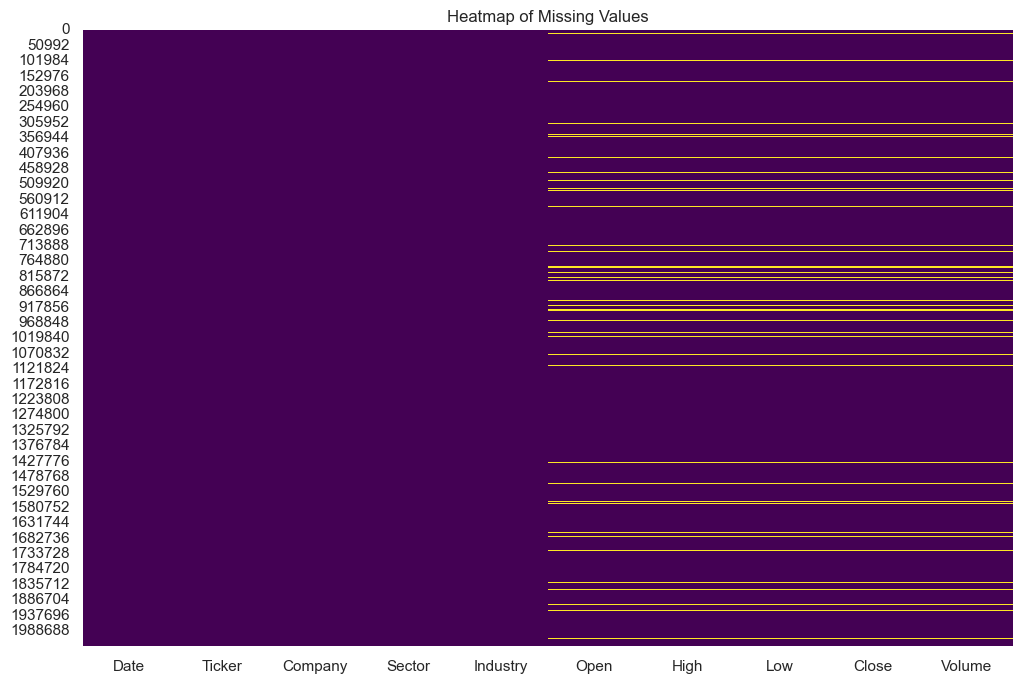

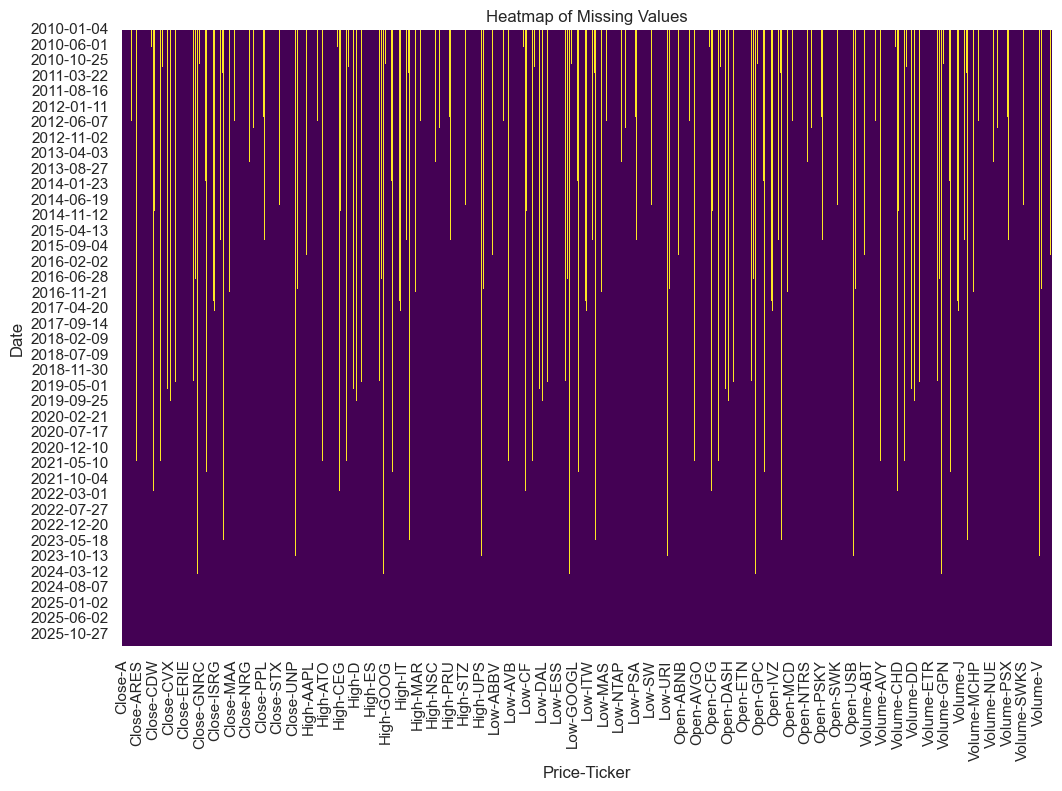

In [7]:
missing = df_final.isnull().sum()

print("Missing Values per column:")
print(missing[missing > 0])

# Create a heatmap of missing values
plt.figure(figsize=(12, 8))
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

# Create a heatmap of missing values
plt.figure(figsize=(12, 8))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

NOTE:
- Missing Heatmap #1 (Long Format)
  - no missing data (?)
  - can be misleading since companies were added and removed since 2010 (Survivorship Bias)
  - Is there columns in which there initially in the S&P 500, but was later removed? 
  - Does the dataset only contain all surviving companies? (Bias in dataset)
- Missing Heatmap #2 (Wide Format - Original)
  - original data
  - columns with empty data due to companies being included or excluded from the S&P 500
  - 

## Zeros in df_final

It was determined later that we need to remove all observations whose volume = 0.

In [8]:
# check for zero values
zero_counts = (df_final[['Open', 'High', 'Low', 'Close', 'Volume']] == 0).sum()
print(zero_counts)

df_final = df_final[df_final['Volume'] > 0]

zero_volume = (df_final[['Open', 'High', 'Low', 'Close', 'Volume']] == 0).sum()
print(zero_volume)


Open         0
High         0
Low          0
Close        0
Volume    3853
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


## Distribution of Prices (Close)



--- Summary Statistics of Raw Data ---
              Open         High          Low        Close           Volume
count 1,916,321.00 1,916,321.00 1,916,321.00 1,916,321.00     1,916,321.00
mean        103.07       104.25       101.87       103.09     7,398,191.11
std         247.15       250.08       244.28       247.20    34,107,173.97
min           0.20         0.21         0.20         0.20            20.00
25%          28.05        28.36        27.73        28.05     1,032,700.00
50%          54.06        54.64        53.47        54.07     2,279,800.00
75%         108.43       109.61       107.21       108.44     5,317,700.00
max       9,914.17     9,964.77     9,794.00     9,924.40 3,692,928,000.00


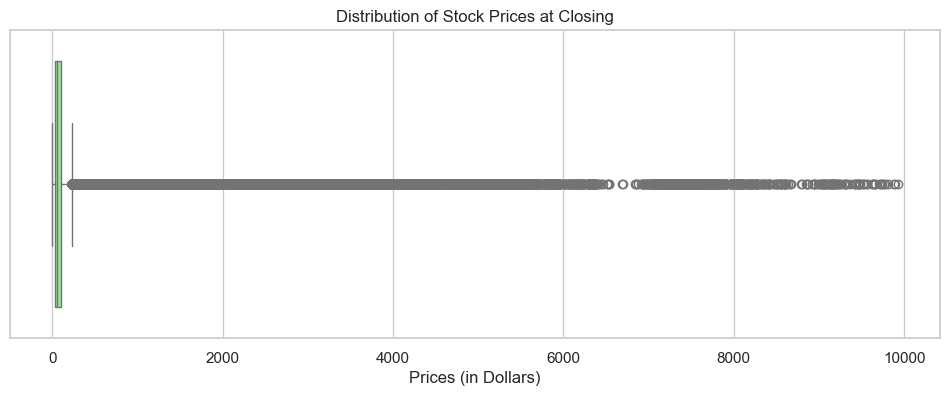

In [9]:
# View the summary statistics of the raw data
print("\n--- Summary Statistics of Raw Data ---")
pd.set_option('display.float_format', '{:,.2f}'.format)
print(df_final[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

plt.figure(figsize=(12, 4))

# We use dropna() for closing prices only
sns.boxplot(x=df_final['Close'], color='lightgreen')
plt.title('Distribution of Stock Prices at Closing')
plt.xlabel('Prices (in Dollars)')
plt.show()

NOTE: Removing the Zeros changed the Minimum Volume to 100!

## Feature Engineering: Returns

The problem with using the pricing data is that not all prices are the same for all stocks. For example, the min for pricing is about $.20 and the max is $9964.77. If we use the percentage returns, the values are more in a range between -100 and 100.


In [10]:
# Grouping by company
grouped = df_final.groupby('Ticker')['Close']

# creating column for Daily return percentage change (from previous day's stock price)
df_final['daily_return'] = grouped.pct_change()

# weekly, monthly, quarterly, and yearly returns (in business trading days)
df_final['weekly_return'] = grouped.pct_change(periods=5) # 1 week (5 days)
df_final['monthly_return'] = grouped.pct_change(periods=21) # 1 month (21 days)
df_final['quarterly_return'] = grouped.pct_change(periods=63) # 3 months (63 days)
df_final['yearly_return'] = grouped.pct_change(periods=252) # 3 months (252 days)

# creating column for our target (next day returns)
df_final['target_next_day_returns'] = grouped.pct_change().shift(-1)
df_final.head()



,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,daily_return,weekly_return,monthly_return,quarterly_return,yearly_return,target_next_day_returns
0,2010-01-04,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.91,20.07,19.75,19.86,"3,815,561.00",NaN,NaN,NaN,NaN,NaN,-0.01
1,2010-01-05,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.80,19.81,19.51,19.64,"4,186,031.00",-0.01,NaN,NaN,NaN,NaN,-0.00
2,2010-01-06,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.57,19.67,19.51,19.57,"3,243,779.00",-0.00,NaN,NaN,NaN,NaN,-0.00
3,2010-01-07,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.53,19.55,19.35,19.55,"3,095,172.00",-0.00,NaN,NaN,NaN,NaN,-0.00
4,2010-01-08,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,19.44,19.57,19.29,19.54,"3,733,918.00",-0.00,NaN,NaN,NaN,NaN,0.00


The creation of returns resulted in several observations (the earliest dates) with NAs. These were results of not having earlier data.

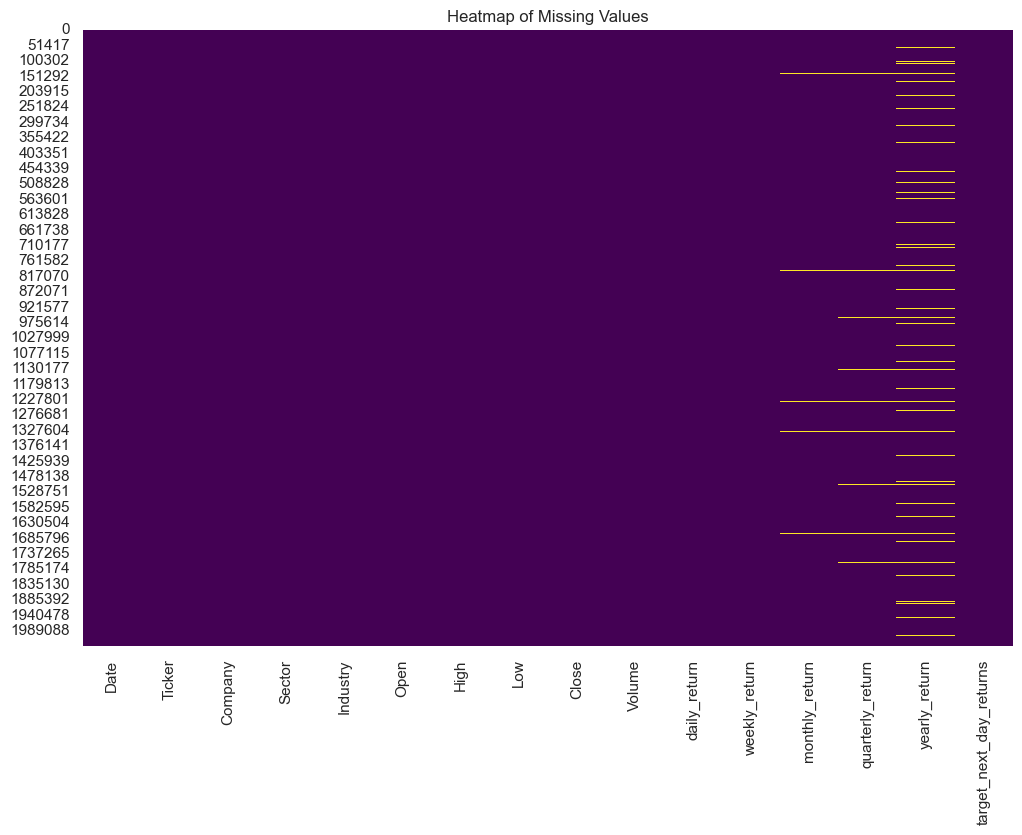

In [11]:
# Create a heatmap of missing values
plt.figure(figsize=(12, 8))
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

## Zero Values and Outlier Detection

Analysis:

No stock valued at Zero. However, Zero Volume indicates that trading was halted that day.

In [12]:
# check for zero values
zero_counts = (df_final[['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'weekly_return', 'monthly_return', 'quarterly_return', 'yearly_return']] == 0).sum()
print(zero_counts)

# Find extreme outliers (Daily Return) if the change is > 50% or < -50%
extreme_outliers = df_final[(df_final['daily_return'] > 0.5) | (df_final['daily_return'] < -0.5)]
print(f"Total extreme anomalies found: {len(extreme_outliers)}")
extreme_outliers

Open                    0
High                    0
Low                     0
Close                   0
Volume                  0
daily_return        11953
weekly_return        4488
monthly_return       1496
quarterly_return      263
yearly_return          93
dtype: int64
Total extreme anomalies found: 13


,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,daily_return,weekly_return,monthly_return,quarterly_return,yearly_return,target_next_day_returns
107016,2016-04-22,AMD,Advanced Micro Devices Inc,Information Technology,Semiconductors,3.19,3.99,3.18,3.99,"143,265,300.00",0.52,0.48,0.49,0.98,0.71,-0.14
144486,2020-03-09,APA,APA Corp (US),Energy,Oil & Gas Exploration & Production,11.56,11.80,8.03,8.22,"28,073,200.00",-0.54,-0.63,-0.67,-0.48,-0.69,0.13
260846,2015-04-13,BLDR,Builders FirstSource Inc,Industrials,Building Products,11.00,11.74,10.50,11.57,"17,377,500.00",0.68,0.68,0.92,0.75,0.37,0.17
506200,2023-06-08,CVNA,Carvana Co,Consumer Discretionary,Specialty Retailers,18.82,26.09,17.63,24.23,"175,781,000.00",0.56,0.53,1.04,1.87,-0.05,-0.21
561226,2016-07-05,DHR,Danaher Corp,Health Care,Life Sciences Tools & Services,65.49,68.01,65.42,68.01,"17,648,801.00",0.61,0.70,0.68,0.77,0.93,0.00
842976,2024-04-11,GL,Globe Life Inc,Financials,Life & Health Insurance,96.96,97.06,38.35,48.41,"36,577,500.00",-0.53,-0.55,-0.60,-0.59,-0.54,0.20
927456,2021-08-04,HOOD,Robinhood Markets Inc,Financials,Investment Banking & Brokerage,54.45,85.00,54.40,70.39,"175,790,500.00",0.50,NaN,NaN,NaN,NaN,-0.28
1438031,2020-03-09,OXY,Occidental Petroleum Corp,Energy,Oil & Gas Exploration & Production,14.65,18.05,11.32,11.76,"104,930,300.00",-0.52,-0.61,-0.69,-0.65,-0.78,0.15
1458017,2019-01-14,PCG,PG&E Corp,Utilities,Multi-Utilities,9.10,9.62,7.69,8.28,"127,198,800.00",-0.52,-0.56,-0.68,-0.82,-0.81,-0.18
1458024,2019-01-24,PCG,PG&E Corp,Utilities,Multi-Utilities,7.81,14.33,7.22,13.79,"82,538,300.00",0.75,0.98,-0.39,-0.71,-0.68,-0.16


Notes:

Zero Volume indicates that trading was halted that day. They must be removed to avoid any errors in calculations resulting in a undefined or an infinity value. Remove them before initiating returns

For outliers, prices may vary by a lot. Comparing daily return percentage change from previous day for each ticker. (This created NAs for first date for each ticker, since there was no information from previous day) Within the whole dataset, there were only 12 outliers with extreme percentage change.

In [13]:
# Example: Checking zero-volume day patterns

# # Assuming df has columns: Open, Close, Volume, Date
# # Check if Open == Close on zero-volume days
# zero_vol_days = df_final[df_final['Volume'] < 1]
# same_prices = zero_vol_days[zero_vol_days['Open'] == zero_vol_days['Close']]

# print(f"Days with 0 volume: {len(zero_vol_days)}")
# print(f"Days with 0 volume AND Open == Close: {len(same_prices)}")

# price_continuity = zero_vol_days.copy()

# # Check if previous day's close matches next day's open
# price_continuity['PrevClose'] = price_continuity.groupby('Ticker')['Close'].shift(1)
# price_continuity['NextOpen'] = price_continuity.groupby('Ticker')['Open'].shift(-1)


# price_continuity['PrevCloseDiff'] = abs(price_continuity['PrevClose'] - price_continuity['Open'])
# price_continuity['NextOpenDiff'] = abs(price_continuity['Close'] - price_continuity['NextOpen'])
# # print(price_continuity[['Date', 'Ticker', 'Open', 'Close', 'PrevClose', 'NextOpen', 'PrevCloseDiff', 'NextOpenDiff']])

# not_same = price_continuity[price_continuity['Open'] != price_continuity['Close']]
# print(not_same[['Date', 'Ticker', 'Open', 'Close', 'PrevClose', 'NextOpen', 'PrevCloseDiff', 'NextOpenDiff']])
# print(not_same.shape)

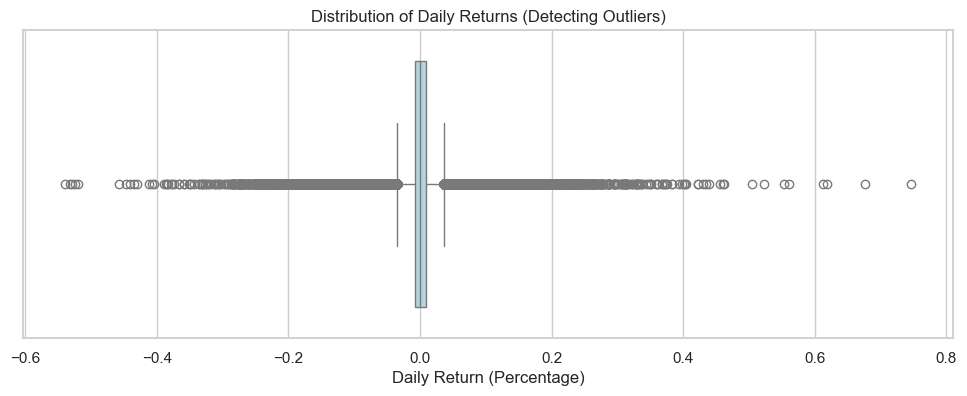

In [14]:
plt.figure(figsize=(12, 4))

# We use dropna() for Daily Return only (There should still be existing NAs depending on how far you want to compare returns)
sns.boxplot(x=df_final['daily_return'].dropna(), color='lightblue')
plt.title('Distribution of Daily Returns (Detecting Outliers)')
plt.xlabel('Daily Return (Percentage)')
plt.show()



## Market and Sector Breakdown


In [15]:
print(df_final[['Sector', 'Industry', 'Company']].isnull().sum())

# Checking for sector counts
unique_companies = df_final.drop_duplicates('Ticker')
sector_counts = unique_companies['Sector'].value_counts()

print(f"\n--- Total Unique Sectors: {len(sector_counts)} ---")
print(sector_counts)

# Checking industry counts
industry_counts = unique_companies['Industry'].value_counts()

print(f"\n--- Total Unique Industries: {len(industry_counts)} ---")
print(industry_counts)



Sector      0
Industry    0
Company     0
dtype: int64

--- Total Unique Sectors: 12 ---
Sector
Industrials               79
Financials                75
Information Technology    70
Health Care               60
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
--                         2
Name: count, dtype: int64

--- Total Unique Industries: 134 ---
Industry
Health Care Equipment                           17
Electric Utilities                              15
Application Software                            14
Semiconductors                                  14
Industrial Machinery & Supplies & Components    14
                                                ..
Brewers                                          1
Wireless Telecommunication Services              1
Passenger Ground Transportation                  1
Homefurnishing Retail   

In [16]:
# LIST: All Sectors and its industries

import string

unique_companies = df_final.drop_duplicates('Ticker').copy()
sector_order = unique_companies['Sector'].value_counts().index.tolist()
alphabet = list(string.ascii_lowercase)

print("--- S&P 500 Sector and Industry Outline ---")

for i, sector_name in enumerate(sector_order):
    # Get the count for the sector
    sector_data = unique_companies[unique_companies['Sector'] == sector_name]
    sector_count = len(sector_data)
    
    # Assign a letter (handles more than 26 sectors if needed)
    letter = alphabet[i] if i < 26 else f"z{i-25}"
    
    print(f"{letter}. {sector_name} ({sector_count} companies)")
    
    # Get and sort industries within this sector by count
    industry_counts = sector_data['Industry'].value_counts()
    
    for j, (industry_name, industry_count) in enumerate(industry_counts.items(), 1):
        # Handle blank or missing industry names for clarity
        display_name = industry_name if pd.notna(industry_name) and str(industry_name).strip() != '' else "[No Data]"
        print(f"   {j}. {display_name} ({industry_count})")

--- S&P 500 Sector and Industry Outline ---
a. Industrials (79 companies)
   1. Industrial Machinery & Supplies & Components (14)
   2. Aerospace & Defense (12)
   3. Building Products (8)
   4. Electrical Components & Equipment (5)
   5. Construction Machinery & Heavy Transportation Equipment (4)
   6. Air Freight & Logistics (4)
   7. Environmental & Facilities Services (4)
   8. Human Resource & Employment Services (3)
   9. Diversified Support Services (3)
   10. Rail Transportation (3)
   11. Passenger Airlines (3)
   12. Construction & Engineering (3)
   13. Research & Consulting Services (2)
   14. Trading Companies & Distributors (2)
   15. Industrial Conglomerates (2)
   16. Cargo Ground Transportation (2)
   17. Data Processing & Outsourced Services (1)
   18. Agricultural & Farm Machinery (1)
   19. Building: Climate Control (1)
   20. Heavy Electrical Equipment (1)
   21. Passenger Ground Transportation (1)
b. Financials (75 companies)
   1. Asset Management & Custody Banks

There are two industries that have dashes. we need to identify them.

In [17]:
# Comparing to oringinal df_info
industry_counts = df_info['Industry'].value_counts(dropna=False)

# to_string() ensures the full list is printed rather than a truncated version
# print(industry_counts.to_string())

# To specifically see which companies have the '-' as their industry:
print("\n--- Companies with '-' as Industry ---")
dashes = df_info[df_info['Industry'] == '-']
print(dashes[['Ticker', 'Company', 'Sector', 'Industry']])


--- Companies with '-' as Industry ---
    Ticker  Company     Sector Industry
147    CRH  CRH PLC  Materials        -


### Facts on S&P 500
- initially though there was an error in data cleaning, but original shows it is like this. 
- Make sure to get current information.
- Strict guidlines on which companies are added and removed. (Dive deeper later.)

SOLS was added in octover 2025 as part of Honeywell spinoff. Spinoffs from large companies get added to S&P 500 immediately.They replaced CarMax.

Qnity on November 2025 (Spin off from DuPont)


---

# Models

## Baseline Model

Since we are predicting if the price goes up or down on the next day, simple linear regression model is used as a baseline. 

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


features = ['daily_return', 'weekly_return', 'monthly_return', 'quarterly_return', 'yearly_return']
target = 'target_next_day_returns'

# Dropping any NAs in new dataframe
df_returns = df_final[features + [target]].dropna()

X = df_returns[features]
y = df_returns[target]

# Splitting the data (80/20)
X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initializing and training the Baseline Model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Predictions and evaluate
preds = baseline_model.predict(X_test)
mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)

rsme_baseline = np.sqrt(mse)
r2_baseline = r2_score(y_test, preds)

actual_direction = np.sign(y_test)
pred_direction = np.sign(preds)

acc_baseline = np.mean(actual_direction == pred_direction)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

print(f"RMSE: {rsme_baseline}")
print(f"R-squared: {r2_baseline}")
print(f"Directional Accuracy: {acc_baseline * 100:.2f}")



MSE: 0.000430208313158665
MAE: 0.01333836470644909
RMSE: 0.020741463621419414
R-squared: 0.0010330169134785683
Directional Accuracy: 52.39


In [19]:
# Creating a Naive prediction

train_mean = y_train.mean()

preds_naive_full = np.full_like(y_test, train_mean)

mse_naive_full = mean_squared_error(y_test, preds_naive_full)
mae_naive_full = mean_absolute_error(y_test, preds_naive_full)

rmse_naive_full = np.sqrt(mse_naive_full)
r2_naive_full = r2_score(y_test, preds_naive_full)

actual_direction_naive_full = np.sign(y_test)
pred_direction_naive_full = np.sign(preds_naive_full)

acc_naive_full = np.mean(actual_direction_naive_full == pred_direction_naive_full)

print(f"MSE (naive): {mse_naive_full}")
print(f"MAE (naive): {mae_naive_full}")

print(f"RMSE: {rmse_naive_full}")
print(f"R-squared: {r2_naive_full}")
print(f"Directional Accuracy: {acc_naive_full * 100:.2f}")

MSE (naive): 0.00043065484373329
MAE (naive): 0.013345124744912994
RMSE: 0.020752225030904275
R-squared: -3.8512439819449185e-06
Directional Accuracy: 52.26


In [20]:
# Creating a Naive prediction

preds_naive = np.zeros(len(y_test))

mse_naive = mean_squared_error(y_test, preds_naive)
mae_naive = mean_absolute_error(y_test, preds_naive)

rmse_naive = np.sqrt(mse_naive)
r2_naive = r2_score(y_test, preds_naive)

actual_direction_naive = np.sign(y_test)
pred_direction_naive = np.sign(preds_naive)

acc_naive = np.mean(actual_direction_naive == pred_direction_naive)

print(f"MSE (naive): {mse_naive}")
print(f"MAE (naive): {mae_naive}")

print(f"RMSE: {rmse_naive}")
print(f"R-squared: {r2_naive}")
print(f"Directional Accuracy: {acc_naive * 100:.2f}")

MSE (naive): 0.00043119847101709456
MAE (naive): 0.013364328530176627
RMSE: 0.02076531894811863
R-squared: -0.0012661832143674445
Directional Accuracy: 0.56


In [21]:
# checking the prediction values
print("Linear Reg. First 5:", preds[:5])
print("Mean Baseline First 5:", preds_naive_full[:5])
print("Zero Baseline First 5:", preds_naive[:5])
print()

# checking the test values
print(y_test.describe())

# Look at the coefficients (weights) the model assigned to your features
print()
print("Intercept:", baseline_model.intercept_)
print("Coefficients:", baseline_model.coef_)
print(features)

Linear Reg. First 5: [ 1.27425546e-03  9.56415325e-04 -2.42517245e-04 -2.70570736e-05
 -6.51456597e-04]
Mean Baseline First 5: [0.00069771 0.00069771 0.00069771 0.00069771 0.00069771]
Zero Baseline First 5: [0. 0. 0. 0. 0.]

count   357,848.00
mean          0.00
std           0.02
min          -0.53
25%          -0.01
50%           0.00
75%           0.01
max           0.62
Name: target_next_day_returns, dtype: float64

Intercept: 0.0007746560697832296
Coefficients: [-0.02249863 -0.0067483   0.00118489 -0.00272703  0.00033938]
['daily_return', 'weekly_return', 'monthly_return', 'quarterly_return', 'yearly_return']


---

## Proposed Model

### Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Prepare Binary Labels
y_train_class = (y_train > 0).astype(int)
y_test_class = (y_test > 0).astype(int)

# 2. Initialize the Random Forest Classifier
# n_jobs=-1 uses all your CPU cores to speed up training
rf_class = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    min_samples_leaf=50, 
    random_state=42, 
    n_jobs=-1
)

# 3. Train the model
rf_class.fit(X_train, y_train_class)

# 4. Make Predictions
preds_rf_class = rf_class.predict(X_test)

# 5. Evaluate results
print(f"Random Forest Directional Accuracy: {accuracy_score(y_test_class, preds_rf_class) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_class, preds_rf_class, target_names=['Down', 'Up']))

Random Forest Directional Accuracy: 52.57%

Classification Report:
              precision    recall  f1-score   support

        Down       0.52      0.07      0.13    170819
          Up       0.53      0.94      0.67    187029

    accuracy                           0.53    357848
   macro avg       0.52      0.51      0.40    357848
weighted avg       0.52      0.53      0.41    357848



### Model 2: XGBoost

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Create the Binary Target
# 1 = Price went up, 0 = Price went down/stayed the same
y_train_class = (y_train > 0).astype(int)
y_test_class = (y_test > 0).astype(int)

# 2. Initialize the Classifier 
# XGBClassifier instead of XGBRegressor
xgb_class = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 3. Train the model
xgb_class.fit(X_train, y_train_class)

# 4. Predict Direction
preds_class = xgb_class.predict(X_test)

# 5. Evaluate results
print(f"Directional Accuracy: {accuracy_score(y_test_class, preds_class) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_class, preds_class, target_names=['Down', 'Up']))

/Users/luisa/anaconda3/envs/myenv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [19:25:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Directional Accuracy: 52.63%

Classification Report:
              precision    recall  f1-score   support

        Down       0.52      0.10      0.17    170819
          Up       0.53      0.92      0.67    187029

    accuracy                           0.53    357848
   macro avg       0.52      0.51      0.42    357848
weighted avg       0.52      0.53      0.43    357848



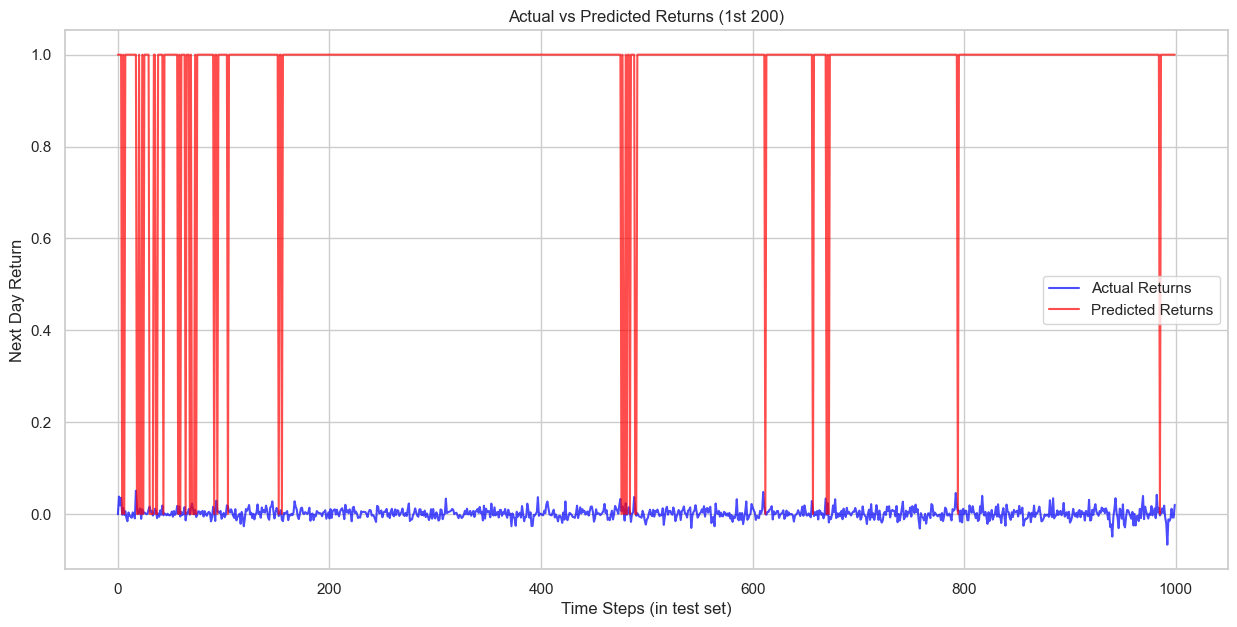

In [24]:
# Plotting acual vs predicted results

plt.figure(figsize=(15,7))

plot_range = 1000

plt.plot(y_test.values[:plot_range], label = "Actual Returns", color = "blue", alpha = 0.7)
plt.plot(preds_class[:plot_range], label = "Predicted Returns", color = "red", alpha = 0.7)

plt.title("Actual vs Predicted Returns (1st 200)")
plt.xlabel("Time Steps (in test set)")
plt.ylabel("Next Day Return")
plt.legend()
plt.grid(True)
plt.show()

In [25]:

model_results = {
    'Baseline (Linear Regression)': {
        'MSE': mse,
        'MAE': mae,
        'RMSE': rsme_baseline,
        'R-squared': r2_baseline,
        'Directional Accuracy': acc_baseline
    },
    'Naive (fill_likes)': {
        'MSE': mse_naive_full,
        'MAE': mae_naive_full,
        'RMSE': rmse_naive_full,
        'R-squared': r2_naive_full,
        'Directional Accuracy': acc_naive_full
    },
    'Naive (Zeros)': {
        'MSE': mse_naive,
        'MAE': mae_naive,
        'RMSE': rmse_naive,
        'R-squared': r2_naive,
        'Directional Accuracy': acc_naive
    },
    'Random Forest': {
        'MSE': mse_rf,
        'MAE': mae_rf,
        'RMSE': rmse_rf,
        'R-squared': r2_rf,
        'Directional Accuracy': acc_rf
    },
    'XGBoost': {
        'MSE': mse_xgb,
        'MAE': mae_xgb,
        'RMSE': rmse_xgb,
        'R-squared': r2_xgb,
        'Directional Accuracy': acc_xgb
    }
}

results_df = pd.DataFrame(model_results).T

results_df['Directional Accuracy'] = results_df['Directional Accuracy'] * 100

# pd.set_option('display.float_format', '{:,.6f}'.format)

results_df

# pd.reset_option('display.float_format')


NameError: name 'mse_rf' is not defined

Random Forest took the longest to compute of all models.

XGBoost - lower MSE, lower MAE, higher R-squared, and higher Directional Accuracy than the Random Forest

Accuracy is about the same for almost all models. There might be other factors calculated to be able to predict prices better. 

**NOTES: Should we filter by company?**

### Feature Engineering: Volume Changes and Risk

When it comes to investing in the stock market, people look into how much of a rick a stock is as well as the amount of stock sold.

Introducing new features relative to volume, returns, and price using rolling window calculations:

- Volume
  - Percentage Change
    - the difference between current and previous volume
  - Relative Volume:
    - Today's volume divided by a rolling volume average window of days
- Returns
  - Volatility (Risk):
    - calculating **standard deviation** of a rolling window of days
- Price
  - Average Price
    - Calculating **percentage distance** the current price is from that moving average of days

In [27]:
# pd.reset_option('display.float_format')

grouped = df_final.groupby('Ticker')

# Volume Change
df_final['daily_vol_change'] = grouped['Volume'].pct_change(periods = 1)

# Relative Volume Change
rolling_vol_21 = grouped['Volume'].transform(lambda x: x.rolling(window=21).mean())
df_final['relative_vol_month'] = df_final['Volume'] / rolling_vol_21

# Volatility (Risk)
df_final['volatility_month'] = grouped['daily_return'].transform(lambda x:x.rolling(window=21).std())

# Moving Average of Price at closing
rolling_close_21 = grouped['Close'].transform(lambda x: x.rolling(window=21).mean())
df_final['average_price_month'] = (df_final['Close'] - rolling_close_21) / rolling_close_21
df_final['average_price_quarter'] = (df_final['Close'] - rolling_close_21) / rolling_close_21
df_final['average_price_year'] = (df_final['Close'] - rolling_close_21) / rolling_close_21

# 1. Convert all Infinity (and negative Infinity) values to NaN
# df_final = df_final.replace([np.inf, -np.inf], np.nan)

# Creating new dataframe with dropped NAs
df_risk = df_final.dropna()
print(df_risk.shape)
df_risk.head(5)


(1789238, 22)


,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,...,monthly_return,quarterly_return,yearly_return,target_next_day_returns,daily_vol_change,relative_vol_month,volatility_month,average_price_month,average_price_quarter,average_price_year
252,2011-01-03,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,26.36,26.73,26.27,26.57,"4,994,075.00",...,0.14,0.29,0.34,-0.01,1.44,1.06,0.01,0.05,0.05,0.05
253,2011-01-04,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,26.64,26.71,26.12,26.32,"5,017,282.00",...,0.11,0.26,0.34,-0.00,0.00,1.06,0.01,0.04,0.04,0.04
254,2011-01-05,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,26.17,26.47,26.01,26.26,"4,519,035.00",...,0.12,0.27,0.34,0.00,-0.10,0.93,0.01,0.03,0.03,0.03
255,2011-01-06,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,26.24,26.54,26.14,26.31,"4,699,097.00",...,0.10,0.25,0.35,0.00,0.04,0.98,0.01,0.03,0.03,0.03
256,2011-01-07,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,26.34,26.52,26.04,26.40,"3,810,948.00",...,0.11,0.23,0.35,0.01,-0.19,0.80,0.01,0.03,0.03,0.03


## Issue: Infinity Values
There was an issue with the next code that informed us of infinity values. Earlier in the EDA, we found that there were over 3500 of volume with 0. Occurs when there is 0 volume on a particular trading day which throws off the percentage change. According to the equation for change in volume:

$$\text{Volume Change} = \frac{V_t - V_{t-1}}{V_{t-1}}$$

If yesterday's volume was 0 and you increased or decreased, you cannot divide by 0. Instead they use infinity as its value.

FIX:
For those volume with zero values, check if pricing changed between opening and closing. (It should not.) Remove them early on to avoid this...

In [28]:
# finding infinity values

# 1. Isolate only the columns that contain numbers (ignore Tickers, Dates, etc.)
numeric_cols = df_final.select_dtypes(include=[np.number])

# 2. Count positive and negative infinities
inf_counts = (numeric_cols == np.inf).sum()
neg_inf_counts = (numeric_cols == -np.inf).sum()

# 3. Display the results
print("--- Positive Infinities ---")
print(inf_counts[inf_counts > 0])

print("\n--- Negative Infinities ---")
print(neg_inf_counts[neg_inf_counts > 0])

# 4. Get the grand total
total_inf = np.isinf(numeric_cols).values.sum()
print(f"\nTotal infinity values: {total_inf}")

--- Positive Infinities ---
Series([], dtype: int64)

--- Negative Infinities ---
Series([], dtype: int64)

Total infinity values: 0


## New Models: Risk and Volume

In [29]:
features2 = ['daily_vol_change', 'relative_vol_month', 'volatility_month', 'average_price_month', 'average_price_quarter', 'average_price_year']
new_features = features + features2
# print(new_features)

X = df_risk[new_features]
y = df_risk['target_next_day_returns']

# Splitting the data
X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.2, shuffle=False)

# Training and evaluating new XGBoost model
xgb2 = XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.5,
    max_depth = 4,
    random_state = 42,
    n_jobs = 1
)

xgb2.fit(X_train, y_train)
preds_xgb2 = xgb2.predict(X_test)

# Metrics
mse_xgb2 = mean_squared_error(y_test, preds_xgb2)
rmse_xgb2 = np.sqrt(mse_xgb2)
mae_xgb2 = mean_absolute_error(y_test, preds_xgb2)
r2_xgb2 = r2_score(y_test, preds_xgb2)

# Accuracy
actual_direction_xgb2 = np.sign(y_test)
pred_direction_xgb2 = np.sign(preds_xgb2)

acc_xgb2 = np.mean(actual_direction_xgb2 == pred_direction_xgb2)


print(f"MSE: {mse_xgb2}")
print(f"MAE: {mae_xgb2}")

print(f"RMSE: {rmse_xgb2}")
print(f"R-squared: {r2_xgb2}")
print(f"Directional Accuracy: {acc_xgb2 * 100:.2f}")

NameError: name 'XGBRegressor' is not defined

In [30]:
#---------------------
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
le_sector = LabelEncoder()
le_industry = LabelEncoder()

df_risk['sector_encoded'] = le_sector.fit_transform(df_risk['Sector'].fillna('Unknown'))
df_risk['industry_encoded'] = le_industry.fit_transform(df_risk['Industry'].fillna('Unknown'))

# Add to features
features3 = ['sector_encoded', 'industry_encoded']
new_features = features + features2 + features3

In [31]:
results_df

NameError: name 'results_df' is not defined

In [ ]:
# Custom formatting function for different decimal places per column
def format_df(df):
    # Define decimal places for each column
    decimal_places = {
        'Open': 2,
        'High': 2,
        'Low': 2,
        'Close': 2,
        'Volume': 0,
        'daily_return': 4,
        'weekly_return': 4,
        'monthly_return': 4,
        'quarterly_return': 4,
        'yearly_return': 4,
        'target_next_day_returns': 4,
        'daily_vol_change': 4,
        'relative_vol_month': 2,
        'volatility_month': 4,
        'average_price_month': 4,
        'average_price_quarter': 4,
        'average_price_year': 4,
    }
    
    # Apply formatting to each column
    for col in df.columns:
        if col in decimal_places and df[col].dtype in ['float64', 'float32']:
            decimals = decimal_places[col]
            df[col] = df[col].apply(lambda x: f'{x:.{decimals}f}' if pd.notna(x) else '')
    
    return df

# Usage: When you want to display a dataframe
print(format_df(df_risk.head(10)))
# print(df_risk.shape)

          Date Ticker                   Company       Sector  \
252 2011-01-03      A  Agilent Technologies Inc  Health Care   
253 2011-01-04      A  Agilent Technologies Inc  Health Care   
254 2011-01-05      A  Agilent Technologies Inc  Health Care   
255 2011-01-06      A  Agilent Technologies Inc  Health Care   
256 2011-01-07      A  Agilent Technologies Inc  Health Care   
257 2011-01-10      A  Agilent Technologies Inc  Health Care   
258 2011-01-11      A  Agilent Technologies Inc  Health Care   
259 2011-01-12      A  Agilent Technologies Inc  Health Care   
260 2011-01-13      A  Agilent Technologies Inc  Health Care   
261 2011-01-14      A  Agilent Technologies Inc  Health Care   

                           Industry   Open   High    Low  Close   Volume  ...  \
252  Life Sciences Tools & Services  26.41  26.78  26.32  26.62  4994075  ...   
253  Life Sciences Tools & Services  26.69  26.76  26.17  26.37  5017282  ...   
254  Life Sciences Tools & Services  26.22  26.52  2

C:\Users\jplac\AppData\Local\Temp\ipykernel_17692\3856039976.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].apply(lambda x: f'{x:.{decimals}f}' if pd.notna(x) else '')


# Evaluation Strategy

## Saving Cleaned Long Form Data (with additional features)

In [ ]:
# checks if file exists before saving, otherwise it does not save
# df_final.to_csv("merged_long.csv")